In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
full = cv2.imread('..\\DATA\\sammy.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)

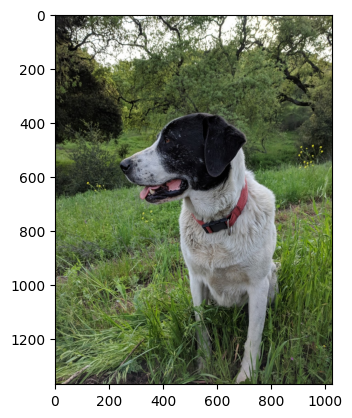

In [7]:
plt.imshow(full)

In [10]:
face = cv2.imread('..\\DATA\\sammy_face.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

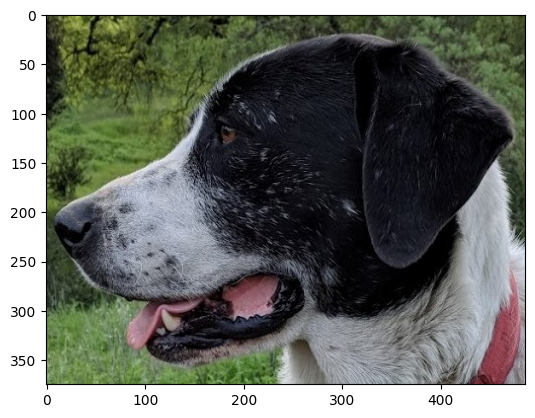

In [11]:
plt.imshow(face)

In [12]:
face.shape

(375, 486, 3)

In [13]:
full.shape

(1367, 1025, 3)

In [14]:
TempMatchingMethods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']


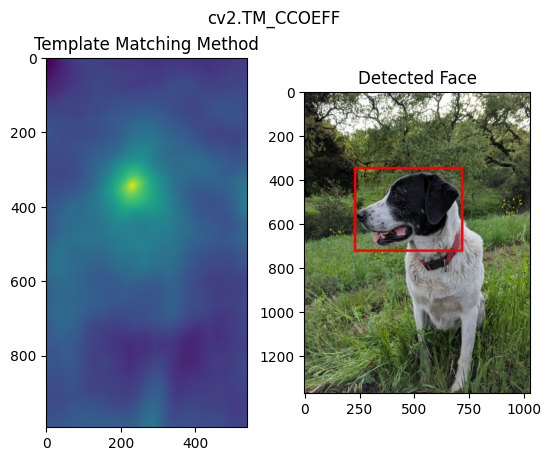

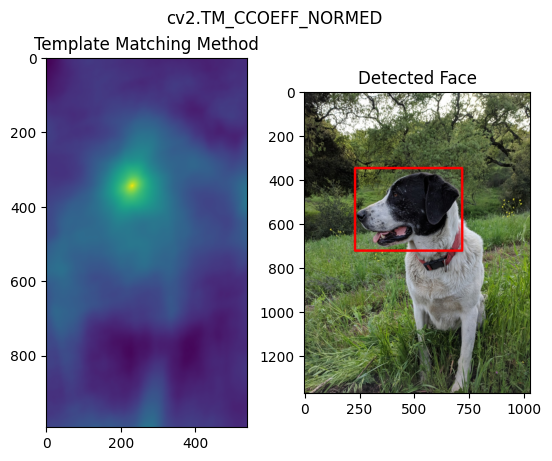

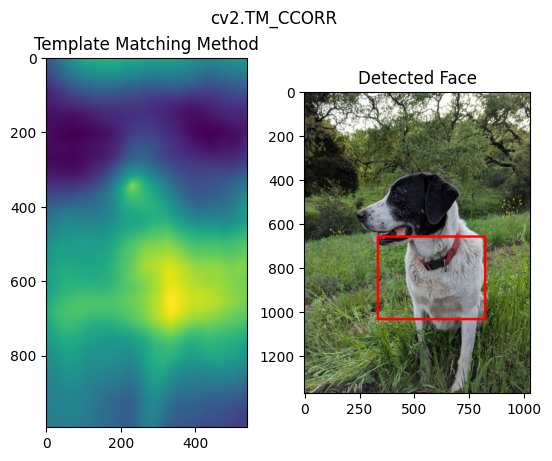

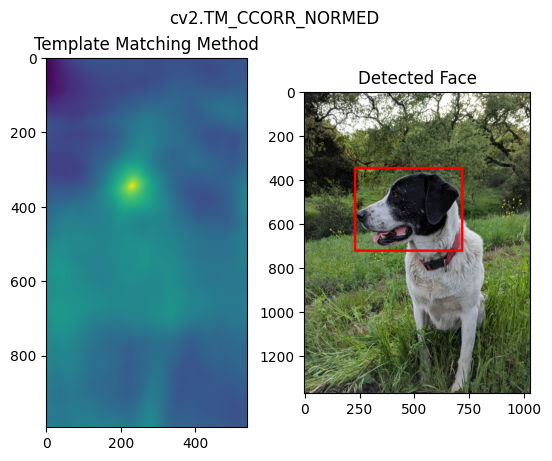

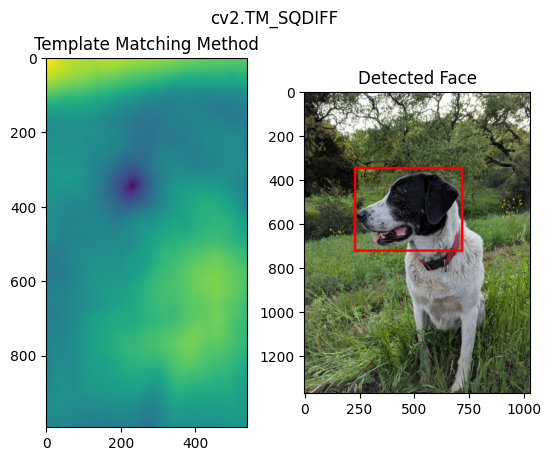

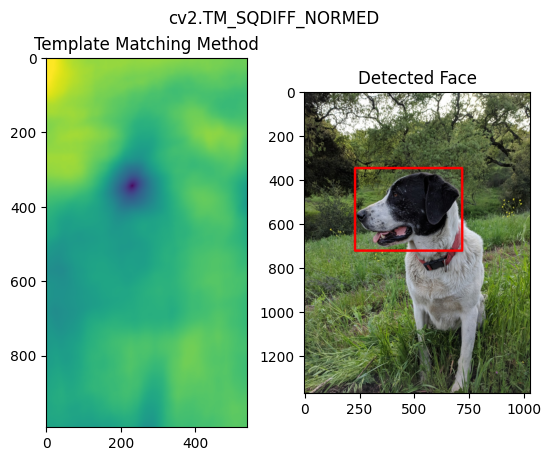

In [16]:
for m in TempMatchingMethods:
    full_copy = full.copy()
    method = eval(m)
    # Apply template Matching
    result = cv2.matchTemplate(full_copy, face, method)
    # Get the best match position
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    
    height, width, _ = face.shape
    bottom_right = (top_left[0] + width, top_left[1] + height)
    cv2.rectangle(full_copy, top_left, bottom_right, (255, 0, 0), 10)

    plt.subplot(121)
    plt.imshow(result)
    plt.title("Template Matching Method")
    plt.subplot(122)
    plt.title("Detected Face")
    plt.imshow(full_copy)
    plt.suptitle(m)

    plt.show()

    print('\n')
    print('\n')    